<a href="https://colab.research.google.com/github/adas754/computer_vision/blob/main/Cats_and_Dogs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CATS AND DOGS DATASET

In [1]:
# importing necessary libraries
import os # os module allows python program to communicate with operating systems to perform file and folder operations
import random
import shutil # shutil module provides functions to copy, move and delete files and folders easily
import numpy as np
import matplotlib.pyplot as plt

# Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

# Image Processing
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img

In [2]:
# Loading the dataset
!pip install kaggle

# Create folder
!mkdir -p dogsvscats_dataset

# Download dataset
!kaggle datasets download -d princelv84/dogsvscats -p dogsvscats_dataset

# Unzip dataset
!unzip dogsvscats_dataset/dogsvscats.zip -d dogsvscats_dataset

Streaming output truncated to the last 5000 lines.
  inflating: dogsvscats_dataset/train/dogs/dog.4419.jpg  
  inflating: dogsvscats_dataset/train/dogs/dog.442.jpg  
  inflating: dogsvscats_dataset/train/dogs/dog.4420.jpg  
  inflating: dogsvscats_dataset/train/dogs/dog.4421.jpg  
  inflating: dogsvscats_dataset/train/dogs/dog.4422.jpg  
  inflating: dogsvscats_dataset/train/dogs/dog.4424.jpg  
  inflating: dogsvscats_dataset/train/dogs/dog.4425.jpg  
  inflating: dogsvscats_dataset/train/dogs/dog.4426.jpg  
  inflating: dogsvscats_dataset/train/dogs/dog.4427.jpg  
  inflating: dogsvscats_dataset/train/dogs/dog.4431.jpg  
  inflating: dogsvscats_dataset/train/dogs/dog.4433.jpg  
  inflating: dogsvscats_dataset/train/dogs/dog.4436.jpg  
  inflating: dogsvscats_dataset/train/dogs/dog.4438.jpg  
  inflating: dogsvscats_dataset/train/dogs/dog.4439.jpg  
  inflating: dogsvscats_dataset/train/dogs/dog.444.jpg  
  inflating: dogsvscats_dataset/train/dogs/dog.4440.jpg  
  inflating: dogsvscats

In [ ]:
# Remove zip
#!rm dogsvscats_dataset/dogsvscats.zip

In [3]:
dataset_path = 'dogsvscats_dataset/train'

In [4]:
os.listdir(dataset_path)

['dogs', 'cats']

In [5]:
cats_path = os.path.join(dataset_path, 'cats')
dogs_path = os.path.join(dataset_path, 'dogs')

cat_images = os.listdir(cats_path)
dog_images = os.listdir(dogs_path)

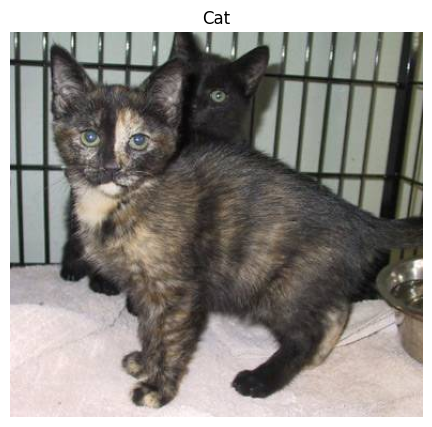

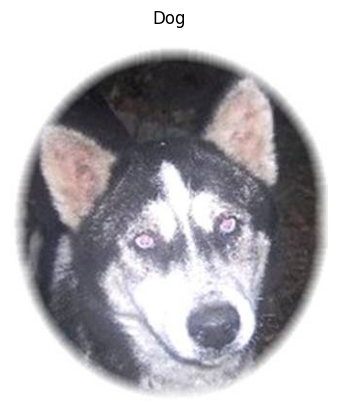

In [6]:
plt.figure(figsize=(10,5))  # Creates a figure of size 10×5

plt.imshow(load_img(os.path.join(cats_path, cat_images[10])))  # Loads and displays the 11th cat image
plt.title("Cat")  # Sets the title as "Cat"
plt.axis('off')  # Hides the axes
plt.show()  # Displays the cat image

plt.imshow(load_img(os.path.join(dogs_path, dog_images[100])))  # Loads and displays the 101st dog image
plt.title("Dog")  # Sets the title as "Dog"
plt.axis('off')  # Hides the axes
plt.show()  # Displays the dog image

In [7]:
img = load_img(os.path.join(cats_path, cat_images[2]))

print("Image Size:", img.size)

Image Size: (499, 375)


In [8]:
from tensorflow.keras.preprocessing.image import img_to_array

img_array = img_to_array(img)

print("Image Shape:", img_array.shape)

Image Shape: (375, 499, 3)


In [9]:
print(img_array[2])

[[242. 234. 245.]
 [154. 145. 164.]
 [ 60.  46.  82.]
 ...
 [132. 106.  93.]
 [142. 113.  99.]
 [148. 116. 105.]]


"Take the images from dataset_path, resize every image to 150×150, normalize its pixels from 0–255 to 0–1, group the images into batches of 32, and assign them to two classes.

In [10]:
# Load data
train_data = ImageDataGenerator(rescale=1./255).flow_from_directory(
    dataset_path,              # Folder containing the training images
    target_size=(150,150),     # Resize every image to 150×150
    batch_size=32,             # Process 32 images at a time
    class_mode='binary'        # Two classes, e.g., cats and dogs
)

Found 20000 images belonging to 2 classes.


In [11]:
model = Sequential()  # Creates the CNN model

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)))  # 32 filters, each 3×3, to detect features like edges and shapes

model.add(MaxPooling2D(2,2))  # 2×2 pooling reduces image size while keeping important features

model.add(Flatten())  # Converts feature maps into a single long list

model.add(Dense(128, activation='relu'))  # 128 neurons learn patterns from the extracted features

model.add(Dense(1, activation='sigmoid'))  # 1 output neuron gives a 0–1 result for binary classification (e.g., cat/dog)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
model.compile(
    optimizer='adam',              # Adjusts the model weights to learn better
    loss='binary_crossentropy',     # Measures how wrong the binary prediction is
    metrics=['accuracy']            # Shows the percentage of correct predictions
)

In [13]:
model.fit(train_data, epochs=5)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 40s 58ms/step - accuracy: 0.6599 - loss: 0.6993
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 35s 56ms/step - accuracy: 0.7558 - loss: 0.5059
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 34s 55ms/step - accuracy: 0.8123 - loss: 0.4136
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 35s 56ms/step - accuracy: 0.8658 - loss: 0.3137
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 35s 55ms/step - accuracy: 0.9140 - loss: 0.2148


In [14]:
datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)  # Normalize pixels and keep 20% of images for validation

val_data = datagen.flow_from_directory(
    dataset_path,                    # Location of the dataset
    target_size=(150,150),            # Resize images to 150×150
    batch_size=32,                    # Process 32 images at a time
    class_mode='binary',              # Two classes, e.g., cat/dog
    subset='validation'               # Use the 20% validation portion
)

Found 4000 images belonging to 2 classes.


In [15]:
test_data = ImageDataGenerator(rescale=1./255).flow_from_directory(
    'dogsvscats_dataset/test',       # Location of test images
    target_size=(150,150),            # Resize images to 150×150
    batch_size=32,                    # Test 32 images at a time
    class_mode='binary'               # Two classes: dog and cat
)

test_loss, test_acc = model.evaluate(test_data)  # Evaluate model on test data

print(f"Test Accuracy: {test_acc*100:.2f}%")  # Print accuracy as a percentage

Found 5000 images belonging to 2 classes.
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 58ms/step - accuracy: 0.7320 - loss: 0.7495
Test Accuracy: 73.20%


In [17]:
from tensorflow.keras.preprocessing import image
import numpy as np

img_path = '/content/images.jfif'       # Path of the image to test

img = image.load_img(img_path, target_size=(150,150))  # Resize image to 150×150

img_array = image.img_to_array(img)     # Convert image into numbers

img_array = img_array / 255.0           # Normalize pixel values to 0–1

img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension

prediction = model.predict(img_array)   # Ask the trained model to predict

if prediction[0][0] > 0.5:
    print("Dog")                        # Probability > 0.5 → Dog
else:
    print("Cat")                        # Probability ≤ 0.5 → Cat

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 770ms/step
Dog


batch dimension is required because the model is designed to process multiple images at once, even when we
 are predicting only one image.